# **Science**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DIAGNOSIS FOR INJECTED SIGNAL
for (q,p) = (3, 5) on 11 sensors with 200 shots and 0.9 signal strength ε
Recovered peak from Bell measurement:  (q*, p*) = (8, 6)
Ground truth peak from Tr(D ρ_signal):   (q, p) = (3, 5)
Ground truth peak from Tr(D signal):     (q, p) = (3, 5)
----------------------------------------------------------------------
Peaks at `(q_0, p_0)` and `(-q_0, -p_0) mod d` in displacement map:
  At injected (q₀,p₀)          = (3,5): 0.24771304181438924540969992
  At symmetric (-q₀,-p₀) mod d = (8,6): 0.24771304181438930092085116
Final decision: (8, 6)
----------------------------------------------------------------------


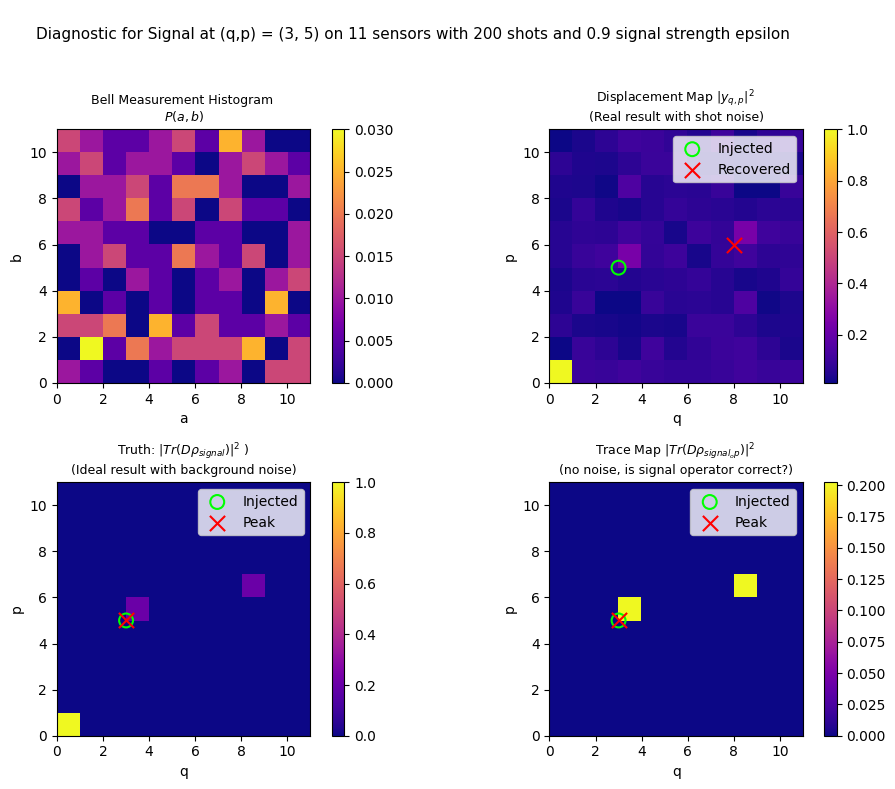

In [2]:
# @title Diagnosis for Bell Protocol

# (Displacement map of Bell Measurement on Conjugate Pairs)
import numpy as np
import matplotlib.pyplot as plt

import random
#seed_value = 42
#random.seed(seed_value)

# Quantum sensor array for photon localization in phase space (creates states and displacement operators)
class QuantumSensorArray:
    def __init__(self, n_sensors, array_length=1.0):
        self.n_sensors = n_sensors
        self.L = array_length
        self.dim = n_sensors  # Hilbert space dimension

    # Constructs the Heisenberg-Weyl displacement operator D_{q,p} = τ^{qp} Z^p X^q
    def get_displacement_operator(self, q_idx, p_idx):
        d = self.dim
        omega = np.exp(2j * np.pi / d)
        Z = np.diag([omega ** j for j in range(d)])
        X = np.roll(np.eye(d), 1, axis=0)
        tau = np.exp(np.pi * 1j * (d + 1) / d)
        D_qp = tau ** (q_idx * p_idx) * np.linalg.matrix_power(Z, p_idx) @ np.linalg.matrix_power(X, q_idx)
        return D_qp

# Constructs Bell basis |Φ_{a,b}> which is eigenbasis for D_{q,p} ⊗ D_{-q,p}. |Φ_{a,b}> = (1/√d) Σ_j exp(2πi*b*j/d) |j+a> ⊗ |-j>
def construct_bell_basis(sensor_array):
    d = sensor_array.dim
    bell_states = []
    for a in range(d):
        for b in range(d):
            state = np.zeros(d * d, dtype=complex)
            for j in range(d):
                phase = np.exp(2j * np.pi * b * j / d)
                ket1_idx = (j + a) % d
                ket2_idx = (-j + d) % d  # Use +d to ensure positive result before modulo
                final_idx = ket1_idx * d + ket2_idx
                state[final_idx] += phase
            state /= np.sqrt(d) # Normalize
            bell_states.append(state)
    return np.array(bell_states).T

# Simulates measurements of rho_tensor in Bell basis with projectors (outer product): bell_state @ bell_state.conj().T
def simulate_bell_measurements(rho_tensor, d, sensor_array, n_shots=1000):
    bell_basis = construct_bell_basis(sensor_array)
    projectors = []
    for i in range(d * d):
        bell_state = bell_basis[:, i:i+1]
        projector = bell_state @ bell_state.conj().T
        projectors.append(projector)

    # Theoretical probabilities calculated inside simulate_bell_measurements according to Born rule: $p_{a,b} = \text{Tr}[\Pi_{a,b} (\rho \otimes \rho^*)]$
    probs = [np.real(np.trace(p @ rho_tensor)) for p in projectors]
    probs = np.maximum(0, probs)
    probs /= np.sum(probs)

    outcomes = np.random.choice(d * d, size=n_shots, p=probs)
    a_vals = outcomes // d
    b_vals = outcomes % d
    return a_vals, b_vals

# Fourier kernel (character) $e^{i \frac{2\pi}{d} (a p - b q)}$</font> = $\chi_{q,p}(a,b)$
# to reconstruct displacement map |y_{q,p}|^2 from Bell measurement outcomes p_{a,b}
# Estimator v_qp is for y_{q,p}^2. The map shows |v_qp| which is |y_{q,p}|^2
def compute_displacement_map(p_ab, d):
    v_qp = np.zeros((d, d), dtype=complex)
    a_coords = np.arange(d)
    b_coords = np.arange(d)

    for q in range(d):
        for p in range(d):
            phase_grid = np.exp(2j * np.pi * (a_coords[:, np.newaxis] * p - b_coords * q) / d)
            v_qp[q, p] = np.sum(p_ab * phase_grid)

    return np.abs(v_qp)

# Special: Computes 'ground truth' displacement map |y_{q,p}|^2 by directly calculating y_{q,p} = Tr(D_{q,p} ρ)
def compute_yqp_via_trace(rho, sensor_array):
    d = sensor_array.dim
    y_qp = np.zeros((d, d), dtype=complex)
    for q in range(d):
        for p in range(d):
            D = sensor_array.get_displacement_operator(q, p)
            y_qp[q, p] = np.trace(D @ rho)
    return np.abs(y_qp) ** 2

# Runs test for a given signal displacement (q_0, p_0).
def test_bell_on_pure_signal(sensor_array, q_0, p_0, epsilon=0.4, n_shots=1000):
    d = sensor_array.dim

    # Step 1: Construct unknown signal state ρ_signal: To create a signal peak at (q₀,p₀) in the displacement basis,
    # the state ρ = (1/d)(I + ε * signal_op) is constructed, where signal_op is Hermitian.
    D_qp_0 = sensor_array.get_displacement_operator(q_0, p_0)
    signal_operator = 0.5 * (D_qp_0.conj().T + D_qp_0)  # The signal is on the D† component of Bloch decomposition
    rho_signal = (1/d) * (np.eye(d) + epsilon * signal_operator)

    # The "pure signal" is the part of the state deviating from the identity.
    pure_signal_density = (epsilon / d) * signal_operator

    # Step 2: Construct the conjugate pair ρ ⊗ ρ* for measurement
    rho_tensor = np.kron(rho_signal, np.conjugate(rho_signal))

    # Step 3: Simulate Bell measurements on the prepared rho_tensor
    a_vals, b_vals = simulate_bell_measurements(rho_tensor, d, sensor_array, n_shots=n_shots)


    # Step 4: Create the Bell outcome histogram from the measurement samples
    p_ab, _, _ = np.histogram2d(a_vals, b_vals, bins=d, range=[[0, d], [0, d]])
    if np.sum(p_ab) > 0:
        p_ab /= np.sum(p_ab)

    # Step 5: Reconstruct the displacement map from the histogram
    displacement_map = compute_displacement_map(p_ab, d)
    q_star, p_star = np.unravel_index(np.argmax(displacement_map), displacement_map.shape)

    # Step 6: Compute ground truth maps for comparison
    trace_map = compute_yqp_via_trace(rho_signal, sensor_array)
    trace_map_signal = compute_yqp_via_trace(pure_signal_density, sensor_array)
    true_qp_from_trace = np.unravel_index(np.argmax(trace_map), trace_map.shape)
    signal_peak = np.unravel_index(np.argmax(trace_map_signal), trace_map_signal.shape)



    # SPECIAL: Find peaks while ignoring the (0,0) artifact
    # Make a copy to not alter the plot
    displacement_map_for_peak_finding = displacement_map.copy()
    trace_map_for_peak_finding = trace_map.copy()
    # Set the (0,0) element to 0 so it's not picked by argmax
    displacement_map_for_peak_finding[0, 0] = 0
    trace_map_for_peak_finding[0, 0] = 0
    # Find the argmax on the modified maps
    q_star, p_star = np.unravel_index(np.argmax(displacement_map_for_peak_finding), displacement_map.shape)
    true_qp_from_trace = np.unravel_index(np.argmax(trace_map_for_peak_finding), trace_map.shape)


    # Print Diagnostics
    print("="*70)
    print(f"DIAGNOSIS FOR INJECTED SIGNAL")
    print(f"for (q,p) = ({q_0}, {p_0}) on {d} sensors with {n_shots} shots and {epsilon} signal strength ε")
    print("="*70)
    print(f"Recovered peak from Bell measurement:  (q*, p*) = ({q_star}, {p_star})")
    print(f"Ground truth peak from Tr(D ρ_signal):   (q, p) = ({int(true_qp_from_trace[0])}, {int(true_qp_from_trace[1])})")
    print(f"Ground truth peak from Tr(D signal):     (q, p) = ({int(signal_peak[0])}, {int(signal_peak[1])})")
    print("-" * 70)

    # Analyze which peak is stronger in the displacement map
    q_neg = (-q_0) % d
    p_neg = (-p_0) % d
    peak1_height = displacement_map[q_0, p_0]
    peak2_height = displacement_map[q_neg, p_neg]
    print(f"Peaks at `(q_0, p_0)` and `(-q_0, -p_0) mod d` in displacement map:")
    print(f"  At injected (q₀,p₀)          = ({q_0},{p_0}): {peak1_height:.26f}")
    print(f"  At symmetric (-q₀,-p₀) mod d = ({q_neg},{p_neg}): {peak2_height:.26f}")
    print(f"Final decision: ({q_star}, {p_star})")
    # Decision based on which peak is higher after Fourier reconstruction,
    # which depends on accumulated shot noise across all measurements.
    print("-" * 70)


    ######## Diagnostic: Manually compute all p_{a,b} = ⟨Φ_{a,b}|ρ⊗ρ*|Φ_{a,b}⟩
    bell_basis = construct_bell_basis(sensor_array)
    bell_probs = []
    for idx in range(d * d):
        phi_ab = bell_basis[:, idx]
        prob = np.real(phi_ab.conj().T @ rho_tensor @ phi_ab)
        bell_probs.append((idx // d, idx % d, prob))  # (a, b, p_{a,b})

    # Sort by descending probability
    bell_probs.sort(key=lambda x: x[2], reverse=True)

    ####### rank probabilities
    #print("Top Bell measurement probabilities")
    #for rank, (a, b, prob) in enumerate(bell_probs[:5]):
    #    print(f"Rank {rank+1}: (a,b) = ({a},{b}), p = {prob:.6f}")
    #print("-" * 70)

    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'\nDiagnostic for Signal at (q,p) = ({q_0}, {p_0}) on {d} sensors with {n_shots} shots and {epsilon} signal strength epsilon', fontsize=11)

    im1 = ax1.imshow(p_ab.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax1.set_title("Bell Measurement Histogram \n$P(a,b)$", fontsize=9)
    ax1.set_xlabel("a")
    ax1.set_ylabel("b")
    fig.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(displacement_map.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax2.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax2.scatter(q_star, p_star, color='red', s=120, marker='x', label='Recovered')
    ax2.set_title("Displacement Map $|y_{q,p}|^2$ \n(Real result with shot noise)", fontsize=9)
    ax2.set_xlabel("q")
    ax2.set_ylabel("p")
    ax2.legend()
    fig.colorbar(im2, ax=ax2)

    im3 = ax3.imshow(trace_map.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax3.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax3.scatter(true_qp_from_trace[0], true_qp_from_trace[1], color='red', s=120, marker='x', label='Peak')
    ax3.set_title("Truth: $|Tr(D \\rho_{signal})|^2$ ) \n(Ideal result with background noise)", fontsize=9)
    ax3.set_xlabel("q")
    ax3.set_ylabel("p")
    ax3.legend()
    fig.colorbar(im3, ax=ax3)

    im4 = ax4.imshow(trace_map_signal.T, origin='lower', cmap='plasma', extent=[0,d,0,d])
    ax4.scatter(q_0, p_0, s=100, facecolors='none', edgecolors='lime', linewidths=1.5, label='Injected')
    ax4.scatter(signal_peak[0], signal_peak[1], color='red', s=120, marker='x', label='Peak')
    ax4.set_title("Trace Map $|Tr(D \\rho_{signal_op})|^2$ \n(no noise, is signal operator correct?)", fontsize=9)
    ax4.set_xlabel("q")
    ax4.set_ylabel("p")
    ax4.legend()
    fig.colorbar(im4, ax=ax4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# EXECUTION
d = 11
sensor_array = QuantumSensorArray(n_sensors=d)
q_0 = 3
p_0 = 5
result = test_bell_on_pure_signal(sensor_array, q_0, p_0, epsilon=0.9, n_shots=200)

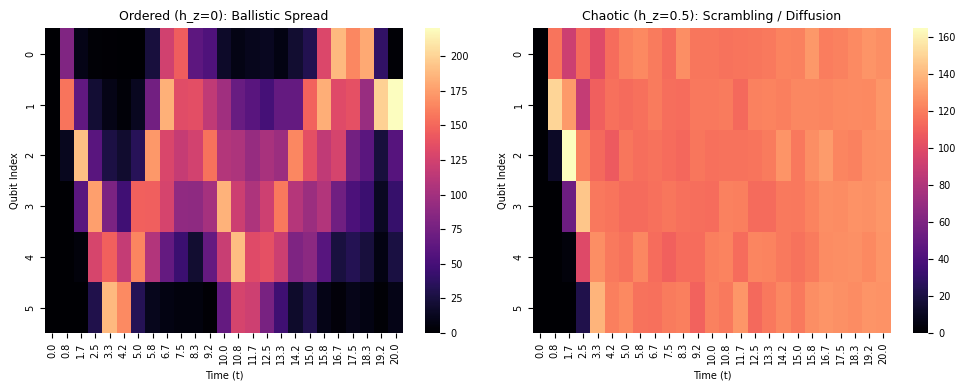

In [4]:
# @title OTOC: Light Cone of Scrambling

!pip install cirq cirq-ionq -q
# ⚠️ Optional: Restart kernel
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits

# OTOC for all qubits over time. Ordered vs Chaotic
from scipy.linalg import norm

def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()

In [ ]:
# @title IBM Quantum Computing

!pip install qiskit qiskit-ibm-runtime qiskit-aer qiskit[visualization] -q
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from IPython.display import display, Markdown

In [ ]:
# 1. Connect to IBM Quantum Service
  # https://eu-de.quantum.cloud.ibm.com/computers
  # https://eu-de.quantum.cloud.ibm.com/docs/de/guides/qpu-information

print("✅ Connect to IBM Quantum")
api_token = userdata.get('ibm-quantum')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_token)

print("\n✅ List of all backends")
available_backends = service.backends()
print("Available Quantum Backends:")
for b in available_backends:
    print(f"- {b.name} ({b.num_qubits} qubits)")

print("\n✅ Select quantum backend")
#backend = service.backend('ibm_strasbourg') # Choose directly
backend = service.least_busy(simulator=False, operational=True) # Choose automatically
print(f"✅ Selected backend: {backend.name} with {backend.num_qubits} qubits") #backend.target.operation_names
print(f"Backend Operations: {backend.target.operation_names}")

✅ Connect to IBM Quantum


qiskit_runtime_service._discover_account:WARNING:2026-09-11 14:49:32,121: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-11 14:49:36,744: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go), the available account instances are: einstein. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:36,749: Loading instance: einstein, plan: pay-as-you-go



✅ List of all backends
Available Quantum Backends:
- ibm_aachen (156 qubits)

✅ Select quantum backend


qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:38,890: Loading instance: einstein, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:39,218: Using instance: einstein, plan: pay-as-you-go


✅ Selected backend: ibm_aachen with 156 qubits
Backend Operations: dict_keys(['x', 'delay', 'reset_2', 'xslow', 'measure_reset_2', 'sx', 'measure_reset', 'rz', 'if_else', 'measure_2', 'reset', 'id', 'measure', 'cz'])


<font color="blue">*Use Case: Two-Qubit Entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) Preparation $|\Phi^+\rangle$*

* Start mit zwei Qubits, $q_0$ und $q_1$, beide initialisiert auf $|0\rangle$, ergibt **$|00\rangle$**.

* Hadamard-Gate versetzt $q_0$ in eine **Superposition**, gleich wahrscheinlich $|0\rangle$ oder $|1\rangle$.
  * Hadamard auf $q_0$: $|00\rangle \xrightarrow{H \otimes I} \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$

* CNOT-Gate zur **Verschränkung** ($q_0$ = Control, $q_1$ = Target):
  * $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$

Dieser Zustand $|\Phi^+\rangle$ ist maximal verschränkt: Messung von $q_0$ legt $q_1$ sofort fest, '00' und '11' je mit $\mathbf{50\%}$ Wahrscheinlichkeit.

*Hinweis zur Bit-Reihenfolge:* Qiskit ordnet die Bits im Classical Register mit Qubit 0 als **niedrigstwertigem** (rechten) Bit — bei diesem symmetrischen Bell-State (00/11) ändert das aber nichts am Ergebnis.

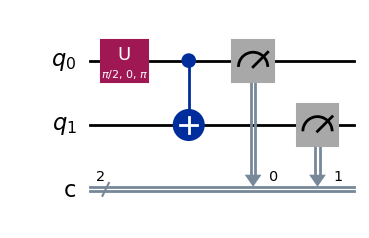

In [ ]:
# 2. Quantum Circuit: Bell State Preparation
  # https://eu-de.quantum.cloud.ibm.com/docs/de/tutorials
qc = QuantumCircuit(2, 2)
qc.h(0)     # Superposition
qc.cx(0, 1) # Entanglement. Test also with swap to see decomposition
qc.measure([0, 1], [0, 1])
#display(qc.draw("mpl"))
qc.decompose().draw("mpl")


Transpiled Circuit for ibm_aachen:


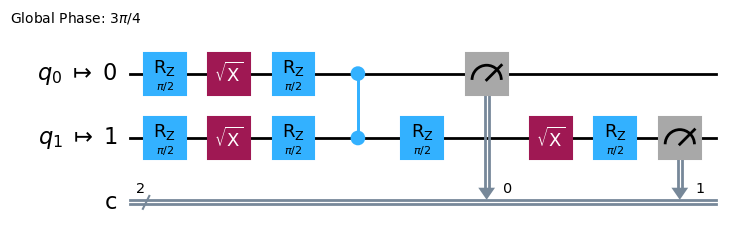

In [ ]:
# 3. Transpile circuit (Minimize number of SWAP operations and use most well-calibrated qubits)
  # https://quantum.cloud.ibm.com/docs/en/guides/transpile#instruction-set-architecture
  # https://quantum.cloud.ibm.com/docs/en/guides/transpiler-stages

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
print(f"\nTranspiled Circuit for {backend.name}:")
display(isa_circuit.draw("mpl"))

In [ ]:
# 4. Local noiseless simulation
print("\n✅ Local noiseless simulation")
shots = 100
local_sampler = LocalSampler()
local_job = local_sampler.run(pubs=[(qc,)], shots=shots)
local_result = local_job.result()
local_counts = local_result[0].data.c.get_counts()
print(local_counts)
with open('noiseless_result.pkl', 'wb') as f:
    pickle.dump(local_counts, f)


✅ Local noiseless simulation
{'11': 52, '00': 48}


In [ ]:
# 5. Noisy simulation
print("\n✅ Noisy simulation")
noisy_backend = AerSimulator.from_backend(backend)
pm_noisy = generate_preset_pass_manager(backend=noisy_backend, optimization_level=1)
noisy_isa_circuit = pm_noisy.run(qc)
noisy_job = noisy_backend.run(noisy_isa_circuit, shots=shots)
noisy_result = noisy_job.result()
noisy_counts = noisy_result.get_counts()
print(noisy_counts)
with open('noisy_result.pkl', 'wb') as f:
    pickle.dump(noisy_counts, f)


✅ Noisy simulation
{'01': 3, '00': 56, '11': 41}



✅ Run job on IBM quantum computer

Submitting job to ibm_aachen...
Job submitted successfully! Job ID: dai1b1e0csts73fm5ung

✅ Job Status
QUEUED

✅ Job metrics
{'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.49.0,qiskit-2.5.2*,qiskit_aer-0.17.2', 'timestamps': {'created': '2026-09-11T14:51:49.784399Z', 'finished': None, 'running': None}}

Measurement Results (Counts):
{'11': 54, '00': 42, '01': 2, '10': 2}


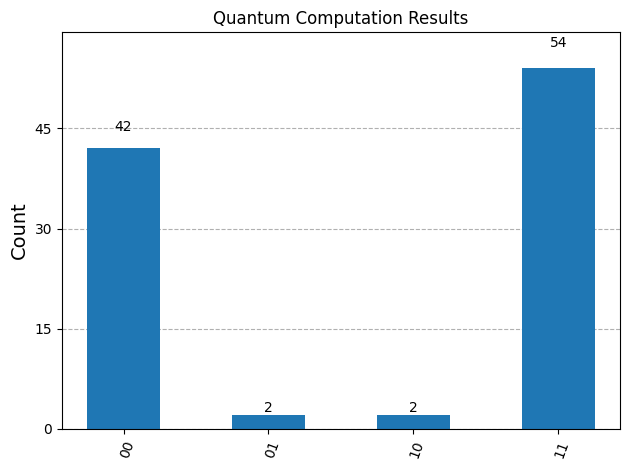

In [ ]:
# 6. Run job on IBM quantum computer ⚠️
  # https://eu-de.quantum.cloud.ibm.com/workloads

print("\n✅ Run job on IBM quantum computer")
sampler = Sampler(mode=backend)
print(f"\nSubmitting job to {backend.name}...")
job = sampler.run(pubs=[(isa_circuit,)], shots=shots)
print(f"Job submitted successfully! Job ID: {job.job_id()}")

# Retrieve a previously submitted job instead:
# job = service.job('JOB_ID')

print("\n✅ Job Status")
print(f"{job.status()}")

print("\n✅ Job metrics")
print(f"{job.metrics()}")

result = job.result()
quantum_counts = result[0].data.c.get_counts()
print("\nMeasurement Results (Counts):")
print(quantum_counts)
with open('quantum_result.pkl', 'wb') as f:
    pickle.dump(quantum_counts, f)

display(plot_histogram(quantum_counts, title="Quantum Computation Results"))


✅ Comparison and Plotting of Results
State  Noiseless  Noisy  Quantum
   00         48     56       42
   01          0      3        2
   10          0      0        2
   11         52     41       54



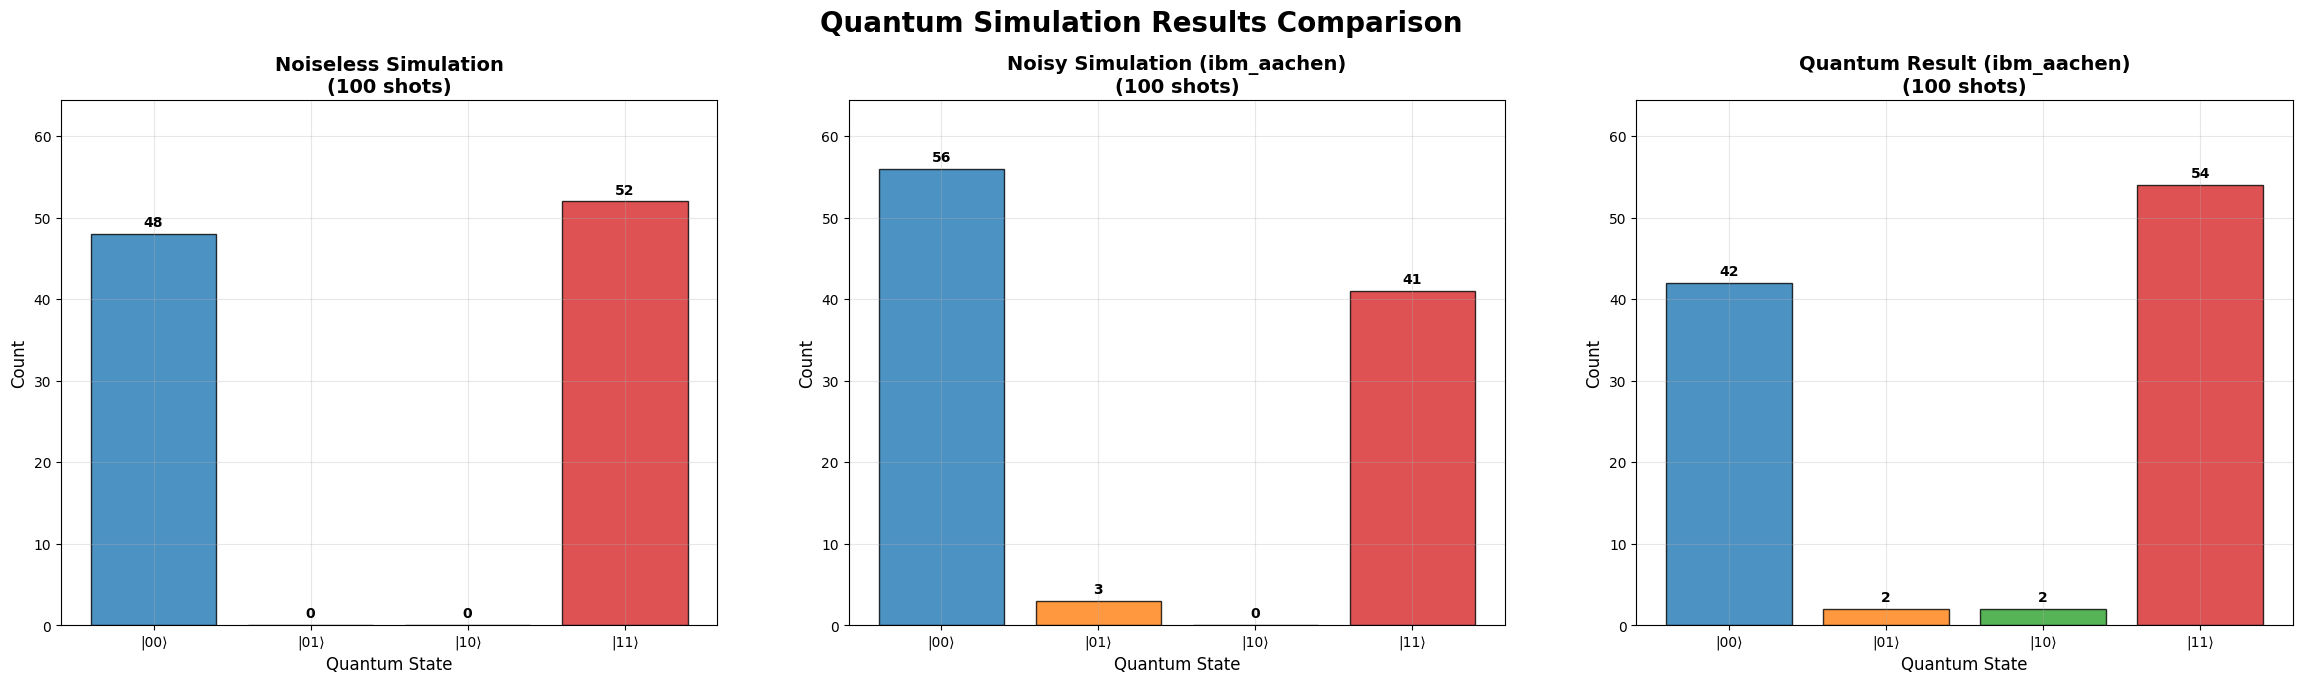

In [ ]:
# 7. Comparison and Plotting of Results
print("\n✅ Comparison and Plotting of Results")
data = {}
for name, fname in [('noiseless', 'noiseless_result.pkl'),
                     ('noisy', 'noisy_result.pkl'),
                     ('quantum', 'quantum_result.pkl')]:
    with open(fname, 'rb') as f:
        data[name] = pickle.load(f)

states = ['00', '01', '10', '11']
comparison_df = pd.DataFrame({
    'State': states,
    'Noiseless': [data['noiseless'].get(s, 0) for s in states],
    'Noisy': [data['noisy'].get(s, 0) for s in states],
    'Quantum': [data['quantum'].get(s, 0) for s in states]
})

print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Plotting
fig = plt.figure(figsize=(24, 7))
fig.suptitle('Quantum Simulation Results Comparison', fontsize=20, fontweight='bold', y=0.98)

state_labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_configs = [
    (1, 'Noiseless', f'Noiseless Simulation\n({shots} shots)'),
    (2, 'Noisy', f'Noisy Simulation ({backend.name})\n({shots} shots)'),
    (3, 'Quantum', f'Quantum Result ({backend.name})\n({shots} shots)')
]

max_count = comparison_df[['Noiseless', 'Noisy', 'Quantum']].max().max()

for idx, col, title in plot_configs:
    ax = plt.subplot(1, 3, idx)
    bars = ax.bar(state_labels, comparison_df[col], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Quantum State', fontsize=12)
    ax.set_ylim(0, max_count * 1.15)
    ax.grid(True, alpha=0.3)
    for bar, count in zip(bars, comparison_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_count*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.subplots_adjust(left=0.05, bottom=0.1, right=0.98, top=0.85, wspace=0.2)
plt.show()